In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('student_clustering.csv')
print("The shape of data is",df.shape)
df.head()

The shape of data is (200, 2)


,cgpa,iq
0,5.13,88
1,5.90,113
2,8.36,93
3,8.27,97
4,5.45,110


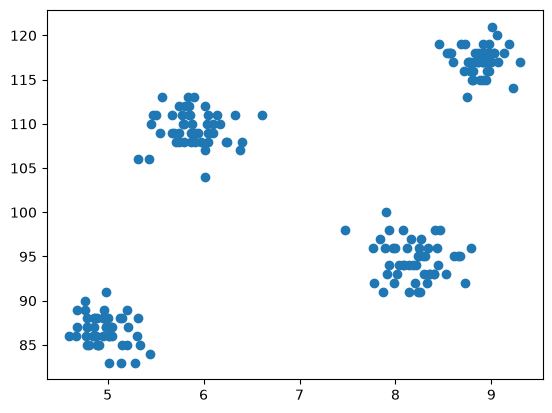

In [3]:
import matplotlib.pyplot as plt
plt.scatter(df['cgpa'],df['iq'])

In [4]:
from sklearn.cluster import KMeans

In [5]:
wcss = []
for i in range(1,15):
    km = KMeans(n_clusters=i)
    km.fit_predict(df)
    wcss.append(km.inertia_)

In [6]:
wcss

[29957.898288,
 4184.14127,
 2362.713349,
 681.96966,
 582.7491892238324,
 503.4758105559798,
 295.43918959431915,
 265.2867266377974,
 215.96747609157507,
 192.65485973122978,
 180.37700315384006,
 136.44328179298773,
 120.6709560222196,
 99.87295336233298]

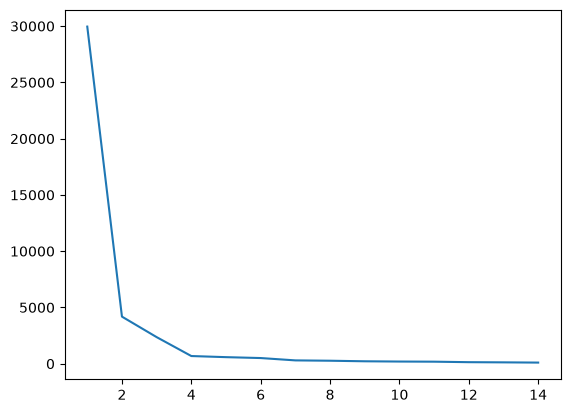

In [7]:
plt.plot(range(1,15),wcss)

In [8]:
X=df.iloc[:,:].values
km = KMeans(n_clusters=4)
y_means = km.fit_predict(X)

In [9]:
y_means

array([3, 1, 0, 0, 1, 1, 0, 2, 1, 0, 3, 1, 0, 3, 1, 0, 1, 0, 1, 1, 0, 3,
       0, 3, 3, 0, 3, 2, 0, 1, 2, 1, 2, 1, 0, 0, 2, 1, 3, 1, 3, 0, 0, 3,
       2, 2, 0, 1, 2, 1, 3, 3, 2, 0, 2, 1, 1, 2, 1, 2, 1, 0, 0, 2, 3, 2,
       0, 3, 1, 0, 1, 2, 0, 3, 1, 2, 1, 2, 3, 0, 0, 2, 1, 3, 2, 3, 2, 1,
       2, 1, 2, 2, 0, 3, 0, 0, 2, 0, 3, 2, 1, 3, 3, 2, 3, 3, 0, 3, 2, 2,
       0, 2, 1, 1, 0, 2, 0, 1, 2, 3, 3, 1, 0, 2, 0, 3, 0, 1, 3, 0, 0, 1,
       3, 3, 1, 2, 1, 3, 0, 0, 0, 3, 1, 3, 3, 2, 3, 2, 1, 3, 2, 3, 2, 2,
       3, 0, 1, 2, 1, 0, 3, 2, 1, 0, 2, 3, 1, 3, 3, 2, 2, 1, 2, 3, 3, 0,
       2, 1, 3, 2, 2, 1, 1, 1, 0, 3, 0, 0, 2, 1, 0, 0, 3, 3, 0, 3, 2, 1,
       1, 2], dtype=int32)

Boolean indexing 

In [12]:
# X[y_means == 0]
# X[y_means == 1]
# X[y_means == 2]
# X[y_means == 3]
X[y_means == 3,1]

array([88., 86., 88., 86., 87., 88., 87., 84., 85., 86., 83., 86., 87.,
       85., 83., 88., 85., 88., 86., 91., 86., 88., 89., 86., 90., 87.,
       87., 85., 87., 83., 86., 87., 85., 87., 87., 88., 88., 85., 86.,
       86., 86., 85., 88., 88., 89., 88., 88., 89., 85., 89.])

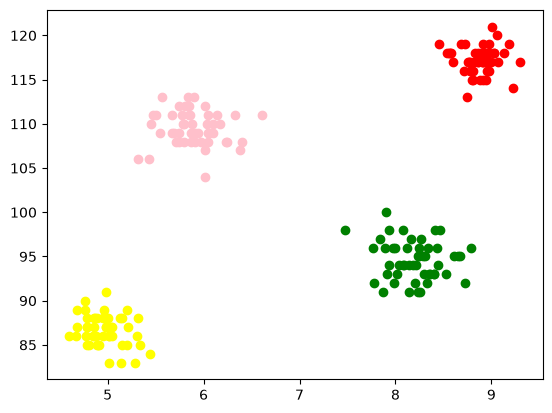

In [14]:
plt.scatter(X[y_means ==0 , 0],X[y_means ==0 , 1], color='green')
plt.scatter(X[y_means ==1 , 0],X[y_means ==1 , 1], color='pink')
plt.scatter(X[y_means ==2 , 0],X[y_means ==2 , 1], color='red')
plt.scatter(X[y_means ==3 , 0],X[y_means ==3 , 1], color='yellow')

### K-Means on 3-D Data

In [15]:
from sklearn.datasets import make_blobs

centroids = [(-5,-5,5),(5,5,-5),(3.5,-2.5,4),(-2.5,2.5,-4)]
cluster_std = [1,1,1,1]

X,y = make_blobs(n_samples=200,cluster_std=cluster_std,centers=centroids,n_features=3,random_state=1)

In [17]:
# X

In [18]:
import plotly.express as px
fig = px.scatter_3d(x=X[:,0], y=X[:,1], z=X[:,2])
fig.show()

In [19]:
wcss = []
for i in range(1,21):
    km = KMeans(n_clusters=i)
    km.fit_predict(X)
    wcss.append(km.inertia_)

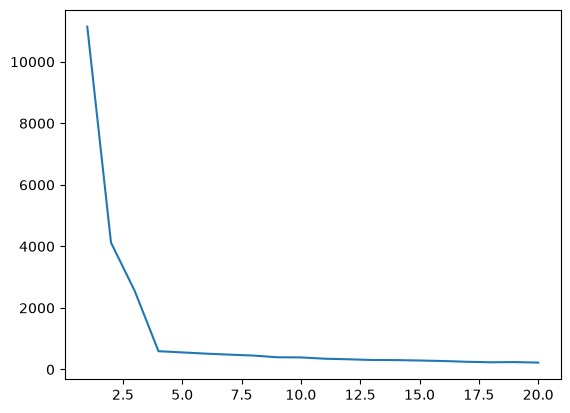

In [20]:
plt.plot(range(1,21),wcss)

Elbow point at 4 

In [21]:
km = KMeans(n_clusters=4)
y_pred = km.fit_predict(X)

In [22]:
df = pd.DataFrame()

df['col1'] = X[:,0]
df['col2'] = X[:,1]
df['col3'] = X[:,2]
df['label'] = y_pred

In [23]:
fig = px.scatter_3d(df,x='col1', y='col2', z='col3',color='label')
fig.show()